In [ ]:
# Portable project paths (GitHub-friendly)
from pathlib import Path

CWD = Path.cwd()
ROOT = CWD if (CWD / 'saved_features').exists() else CWD.parent
FEATURE_DIR = ROOT / 'saved_features'
MODEL_PATH = ROOT / 'task1' / 'model.pth'
VALIDATION_DIR = ROOT / 'validation_data'

print('ROOT:', ROOT)
print('FEATURE_DIR exists:', FEATURE_DIR.exists())
print('MODEL_PATH exists:', MODEL_PATH.exists())


In [21]:
import torch
import torch.nn as nn
import numpy as np

from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.metrics.pairwise import cosine_similarity

In [27]:
import pandas as pd

index_df = pd.read_csv(str(ROOT / "validation_data" / "index_test.csv"))
anomaly_df = pd.read_csv(str(ROOT / "validation_data" / "anomaly-labels.csv"))

In [28]:
index_df["shard_clean"] = index_df["shard"].str.replace(".tar", "", regex=False)

In [29]:
used_shards = [
    "frames-000000", "frames-000001", "frames-000004",
    "frames-000006", "frames-000007", "frames-000009",
    "frames-000010", "frames-000012", "frames-000021",
    "frames-000026", "frames-000033", "frames-000036",
    "frames-000048", "frames-000049", "frames-000051",
    "frames-000063", "frames-000066", "frames-000067",
    "frames-000072", "frames-000073", "frames-000077",
    "frames-000079", "frames-000080", "frames-000081",
    "frames-000084", "frames-000085", "frames-000086",
    "frames-000088", "frames-000089", "frames-000092",
    "frames-000094", "frames-000095", "frames-000097",
    "frames-000102", "frames-000120", "frames-000123",
    "frames-000157", "frames-000160", "frames-000172"
]

In [30]:
index_filtered = index_df[index_df["shard_clean"].isin(used_shards)].reset_index(drop=True)

In [31]:
import numpy as np

labels = np.zeros(len(index_filtered), dtype=int)

for _, row in anomaly_df.iterrows():
    start = row["start_timestamp"]
    end = row["end_timestamp"]
    label = row["label"]

    mask = (
        (index_filtered["timestamp_utc_ms"] >= start) &
        (index_filtered["timestamp_utc_ms"] <= end)
    )

    labels[mask] = label

In [33]:
test_features = np.load("{ROOT}/saved_features/test_features_full.npy")

print(len(test_features), len(labels))

384714 384714


In [34]:
print(test_features.shape, labels.shape)
print("Unique labels:", np.unique(labels))
print("Anomaly ratio:", np.mean(labels != 0))

(384714, 2048) (384714,)
Unique labels: [-1  0  3 11 15 18 20 26 28 29 31 32]
Anomaly ratio: 0.027347588078416692


In [35]:
def make_sequences(features, window=8, stride=5):
    sequences = []

    for i in range(0, len(features) - window, stride):
        sequences.append(features[i:i+window])

    return np.array(sequences)

In [36]:
test_features_seq = make_sequences(test_features)

In [37]:
def make_seq_labels(labels, window=8, stride=5):
    seq_labels = []

    for i in range(0, len(labels) - window, stride):
        seq = labels[i:i+window]

        if np.any(seq != 0):
            vals, counts = np.unique(seq[seq != 0], return_counts=True)
            seq_labels.append(vals[np.argmax(counts)])
        else:
            seq_labels.append(0)

    return np.array(seq_labels)

In [38]:
y = make_seq_labels(labels)

In [39]:
print(test_features_seq.shape, len(y))

(76942, 8, 2048) 76942


In [40]:
def encode(x):
    with torch.no_grad():
        x = model.input_proj(x)
        z = model.transformer(x)
    return z

In [41]:
def extract_latents(features, batch_size=256):
    latents = []

    for i in range(0, len(features), batch_size):
        batch = features[i:i+batch_size]
        batch = torch.tensor(batch, dtype=torch.float32).to(device)

        z = encode(batch)

        # collapse sequence → single vector
        z = z.mean(dim=1)

        latents.append(z.cpu().numpy())

    return np.vstack(latents)

Z = extract_latents(test_features_seq)

In [42]:
print("Z shape:", Z.shape)

Z shape: (76942, 256)


In [43]:
from sklearn.decomposition import PCA

concepts = {
    "collision": [17,18,19],
    "driving": [10,11,12,30,31],
    "lane": [3,20,28,29],
    "waiting": [15]
}

concept_vectors = {}

for name, labels_list in concepts.items():
    mask = np.isin(y, labels_list)
    embeddings = Z[mask]

    if len(embeddings) < 20:
        print(name, "skipped (too few samples)")
        continue

    pca = PCA(n_components=1)
    pca.fit(embeddings)

    vec = pca.components_[0]
    vec = vec / np.linalg.norm(vec)

    concept_vectors[name] = vec

    print(name,
          "samples:", len(embeddings),
          "variance:", pca.explained_variance_ratio_[0])

collision skipped (too few samples)
driving samples: 222 variance: 0.28151911
lane samples: 1649 variance: 0.586455
waiting samples: 39 variance: 0.5420023


/Users/ssweeti/Desktop/anomaly_detection_proejct3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/ssweeti/Desktop/anomaly_detection_proejct3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/ssweeti/Desktop/anomaly_detection_proejct3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/ssweeti/Desktop/anomaly_detection_proejct3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/ssweeti/Desktop/anomaly_detection_proejct3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/ssweeti/Desktop/anomaly_detectio

In [44]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score

interpretability = {}

for name, vec in concept_vectors.items():
    sims = cosine_similarity(Z, vec.reshape(1,-1)).flatten()
    binary_labels = np.isin(y, concepts[name]).astype(int)

    auc = roc_auc_score(binary_labels, sims)

    # fix direction
    if auc < 0.5:
        vec = -vec
        sims = cosine_similarity(Z, vec.reshape(1,-1)).flatten()
        auc = roc_auc_score(binary_labels, sims)
        concept_vectors[name] = vec

    interpretability[name] = auc
    print(name, "Interpretability AUC:", auc)

driving Interpretability AUC: 0.7705904940393992
lane Interpretability AUC: 0.5324621120141143
waiting Interpretability AUC: 0.6864398274616341


/Users/ssweeti/Desktop/anomaly_detection_proejct3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ssweeti/Desktop/anomaly_detection_proejct3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ssweeti/Desktop/anomaly_detection_proejct3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ssweeti/Desktop/anomaly_detection_proejct3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ssweeti/Desktop/anomaly_detection_proejct3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ssweeti/Desktop/anomaly_detection_proejct3/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py

In [45]:
def reconstruction_error(x):
    with torch.no_grad():
        x = torch.tensor(x, dtype=torch.float32).to(device)
        recon = model(x)
        loss = ((recon - x)**2).mean(dim=(1,2))
    return loss.cpu().numpy()

score_original = reconstruction_error(test_features_seq)

In [46]:
alphas = [-0.5, -0.3, -0.1, 0.1, 0.3, 0.5]

for name, vec in concept_vectors.items():
    binary_labels = np.isin(y, concepts[name]).astype(int)

    baseline_auc = roc_auc_score(binary_labels, score_original)
    print("\n", name, "baseline:", baseline_auc)

    for alpha in alphas:
        Z_steered = Z + alpha * vec

        # expand back to sequence
        Z_seq = np.repeat(Z_steered[:, None, :], 8, axis=1)

        with torch.no_grad():
            z_tensor = torch.tensor(Z_seq, dtype=torch.float32).to(device)
            recon = model.decoder(z_tensor)

            loss = ((recon - torch.tensor(test_features_seq).to(device))**2).mean(dim=(1,2))

        score = loss.cpu().numpy()
        auc = roc_auc_score(binary_labels, score)

        print("alpha", alpha, "AUC:", auc)


 driving baseline: 0.7866056456613025
alpha -0.5 AUC: 0.7871971260885495
alpha -0.3 AUC: 0.7868824213942828
alpha -0.1 AUC: 0.7865804868998298
alpha 0.1 AUC: 0.7862951096299637
alpha 0.3 AUC: 0.7860093800787231
alpha 0.5 AUC: 0.7857398261139138

 lane baseline: 0.847319201911156
alpha -0.5 AUC: 0.8545578443146511
alpha -0.3 AUC: 0.8517791223334606
alpha -0.1 AUC: 0.8489525943913616
alpha 0.1 AUC: 0.8460998982128899
alpha 0.3 AUC: 0.843244028662571
alpha 0.5 AUC: 0.8404111499496565

 waiting baseline: 0.8181286982569117
alpha -0.5 AUC: 0.8198209732740245
alpha -0.3 AUC: 0.8188683913168004
alpha -0.1 AUC: 0.8179378151030753
alpha 0.1 AUC: 0.8169782313183741
alpha 0.3 AUC: 0.8159918071950112
alpha 0.5 AUC: 0.8150515617909608


In [47]:
from sklearn.metrics import brier_score_loss

def normalize(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

binary_labels = np.isin(y, concepts["driving"]).astype(int)

score_orig = normalize(score_original)

Z_steered = Z + 0.5 * concept_vectors["driving"]
Z_seq = np.repeat(Z_steered[:, None, :], 8, axis=1)

with torch.no_grad():
    z_tensor = torch.tensor(Z_seq, dtype=torch.float32).to(device)
    recon = model.decoder(z_tensor)

    loss = ((recon - torch.tensor(test_features_seq).to(device))**2).mean(dim=(1,2))

score_steered = normalize(loss.cpu().numpy())

print("Brier original:", brier_score_loss(binary_labels, score_orig))
print("Brier steered:", brier_score_loss(binary_labels, score_steered))

Brier original: 0.1801931352822375
Brier steered: 0.18409135548393404


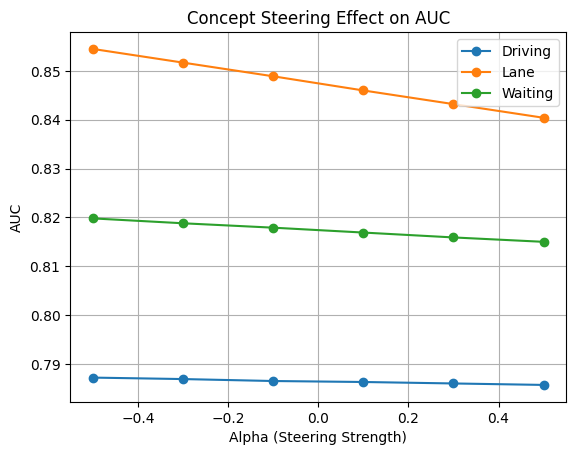

In [48]:
import matplotlib.pyplot as plt

alphas = [-0.5, -0.3, -0.1, 0.1, 0.3, 0.5]

# fill your values
driving_auc = [0.7872, 0.7869, 0.7865, 0.7863, 0.7860, 0.7857]
lane_auc = [0.8545, 0.8517, 0.8489, 0.8460, 0.8432, 0.8404]
waiting_auc = [0.8198, 0.8188, 0.8179, 0.8169, 0.8159, 0.8150]

plt.figure()
plt.plot(alphas, driving_auc, marker='o', label='Driving')
plt.plot(alphas, lane_auc, marker='o', label='Lane')
plt.plot(alphas, waiting_auc, marker='o', label='Waiting')

plt.xlabel("Alpha (Steering Strength)")
plt.ylabel("AUC")
plt.title("Concept Steering Effect on AUC")
plt.legend()
plt.grid()

plt.show()

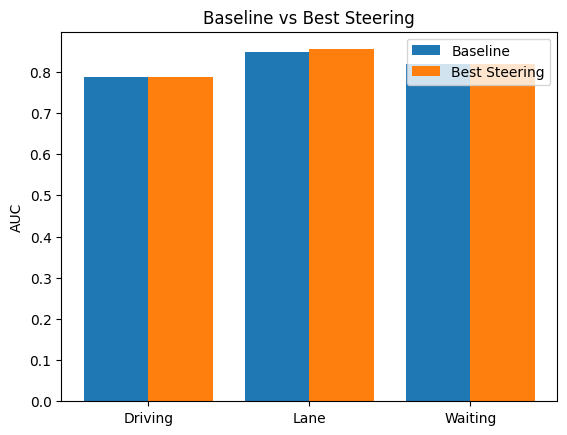

In [49]:
concepts = ["Driving", "Lane", "Waiting"]

baseline = [0.7866, 0.8473, 0.8181]
best = [0.7872, 0.8545, 0.8198]

x = np.arange(len(concepts))

plt.figure()
plt.bar(x - 0.2, baseline, width=0.4, label="Baseline")
plt.bar(x + 0.2, best, width=0.4, label="Best Steering")

plt.xticks(x, concepts)
plt.ylabel("AUC")
plt.title("Baseline vs Best Steering")
plt.legend()

plt.show()

Interpretability Bar Chart

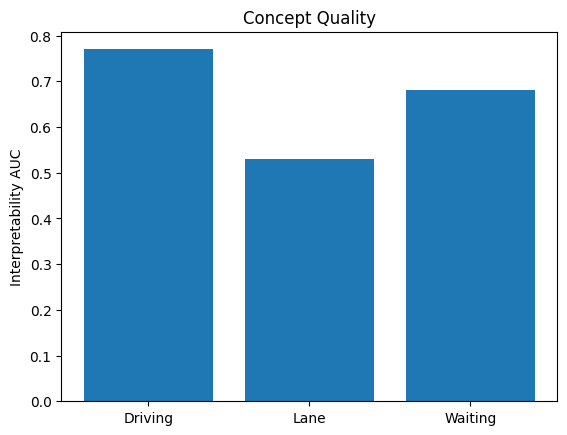

In [50]:
concepts = ["Driving", "Lane", "Waiting"]
values = [0.77, 0.53, 0.68]

plt.figure()
plt.bar(concepts, values)

plt.ylabel("Interpretability AUC")
plt.title("Concept Quality")
plt.show()

In [51]:
np.save("Z.npy", Z)
np.save("y.npy", y)

# save concept vectors
import pickle
with open("concept_vectors.pkl", "wb") as f:
    pickle.dump(concept_vectors, f)

In [52]:
np.save("test_seq.npy", test_features_seq)